In [1]:
import random
import math
from collections import defaultdict
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


class BlackJack:
    deck_template = {
        11: 4,
        10: 16,
        9: 4,
        8: 4,
        7: 4,
        6: 4,
        5: 4,
        4: 4,
        3: 4,
        2: 4
    }

    def __init__(self):
        self.deck = BlackJack.deck_template.copy()
        self.player_hand = []
        self.dealer_hand = []
        self.deal()

    def draw(self):
        """Draw a card from the deck."""
        cards, weights = list(self.deck.keys()), list(self.deck.values())
        card = random.choices(cards, weights=weights)[0]
        self.deck[card] -= 1
        if self.deck[card] == 0:
            del self.deck[card]
        return card

    def hand_value(self, hand):
        """Return (hard_sum, soft_sum) for a hand."""
        hard = sum(1 if c == 11 else c for c in hand)
        soft = hard
        aces = hand.count(11)
        while aces > 0 and soft + 10 <= 21:
            soft += 10
            aces -= 1
        return hard, soft

    def deal(self):
        """Initial deal for player and dealer."""
        self.player_hand = [self.draw()]
        self.dealer_hand = [self.draw()]
        self.player_hand.append(self.draw())
        self.dealer_hand.append(self.draw())

    def player_values(self):
        return self.hand_value(self.player_hand)

    def dealer_values(self):
        return self.hand_value(self.dealer_hand)

    @property
    def dealer_shown(self):
        return self.dealer_hand[1]

    def dealer_play(self):
        """Dealer hits until reaching hard/soft ≥ 17."""
        while True:
            hard, soft = self.dealer_values()
            best = soft if soft <= 21 else hard
            if best >= 17:
                return best
            self.dealer_hand.append(self.draw())

    def result(self):
        """Compute reward for player."""
        player_hard, player_soft = self.player_values()
        player_best = player_soft if player_soft <= 21 else player_hard
        if player_best > 21:
            return -1  # player busts

        dealer_best = self.dealer_play()
        if dealer_best > 21:
            return 1
        if player_best > dealer_best:
            return 1
        elif player_best == dealer_best:
            return 0
        else:
            return -1


MWU win rate: 41.56% | CFR win rate: 38.43% after 1000000 rounds


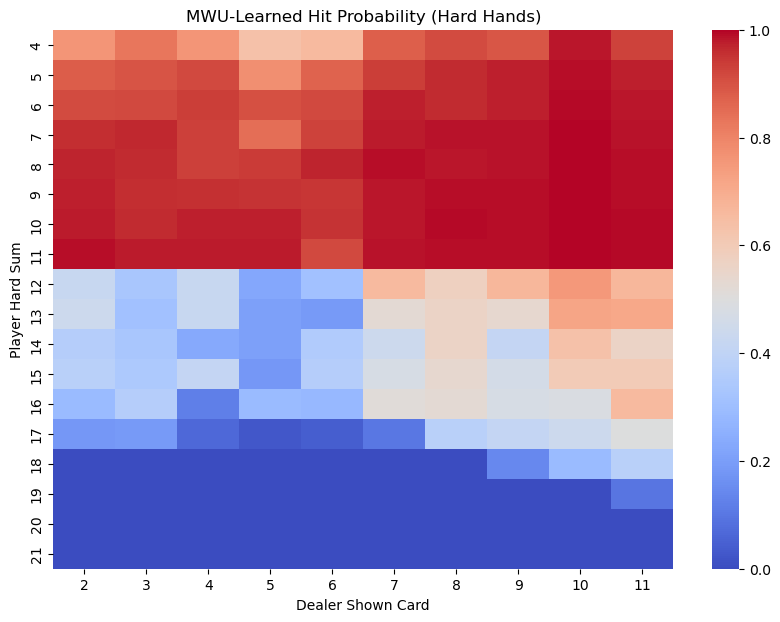

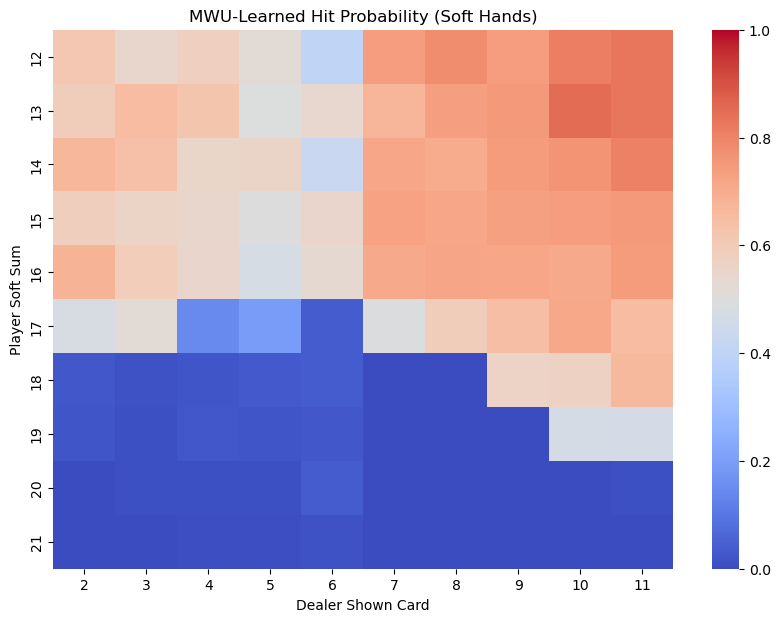

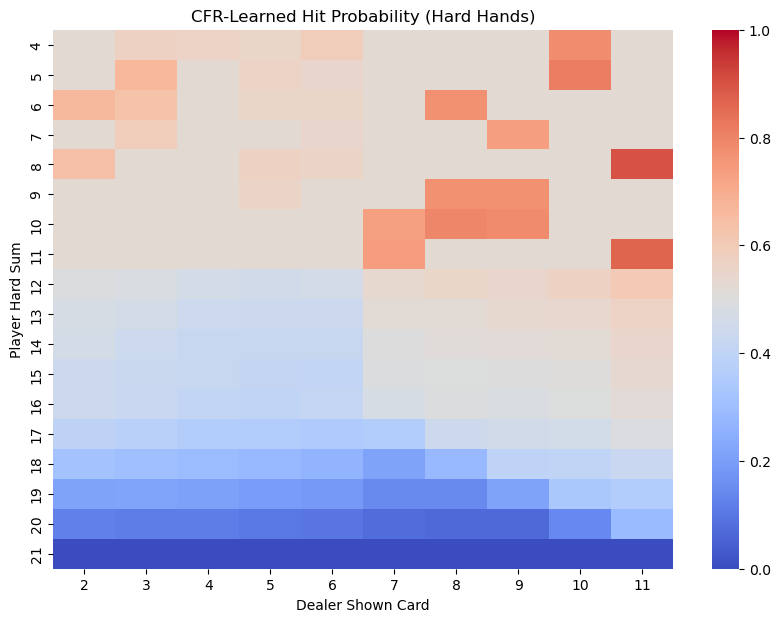

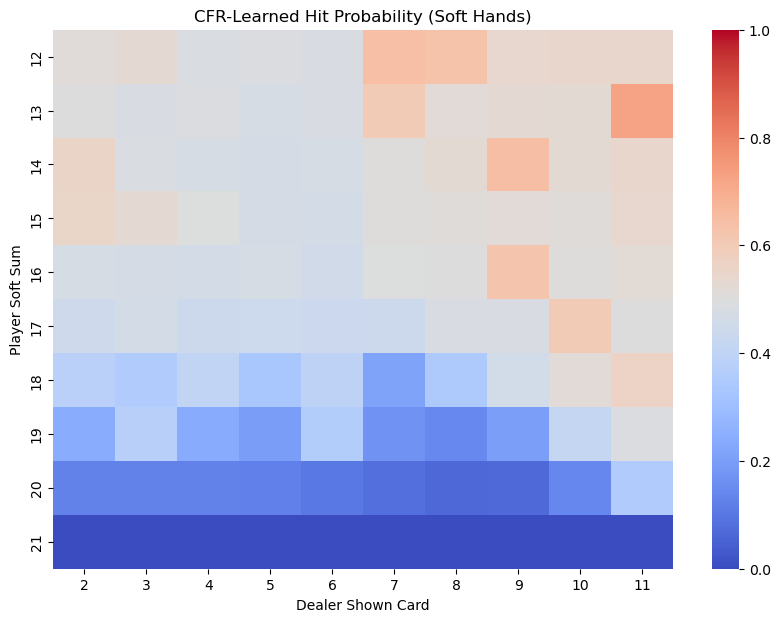

In [ ]:

class MWUAgent:
    def __init__(self, eta=0.05):
        self.eta = eta
        self.weights = defaultdict(lambda: [0.5, 0.5])  # [hit, stand]

    def policy(self, state):
        return self.weights[state]

    def act(self, state):
        probs = self.policy(state)
        return random.choices(["hit", "stand"], weights=probs)[0]

    def update(self, state, action, reward):
        p_hit, p_stand = self.weights[state]

        # MWU update on probabilities directly
        if action == "hit":
            p_hit *= math.exp(self.eta * reward)
        else:
            p_stand *= math.exp(self.eta * reward)

        # Renormalize to stay in [0,1] simplex
        total = p_hit + p_stand
        if total == 0:
            p_hit, p_stand = 0.5, 0.5
        else:
            p_hit /= total
            p_stand /= total

        self.weights[state] = [p_hit, p_stand]


class CFRAgent:
    def __init__(self, eta=0.05):
        self.eta = eta  # used for averaging speed
        self.regret_sum = defaultdict(lambda: [0.0, 0.0])  # cumulative regrets [hit, stand]
        self.strategy_sum = defaultdict(lambda: [0.5, 0.5])  # running average policy

    def policy(self, state):
        regrets = self.regret_sum[state]
        pos_regrets = [max(r, 0.0) for r in regrets]
        total = sum(pos_regrets)
        if total > 0:
            probs = [r / total for r in pos_regrets]
        else:
            probs = [0.5, 0.5]
        return probs

    def act(self, state):
        probs = self.policy(state)
        return random.choices(["hit", "stand"], weights=probs)[0]

    def update(self, state, action, reward):
        # Estimate counterfactual regret for each action given observed reward
        # CFR normally requires both actions' rewards; here we approximate
        # using a simple one-step update where only the chosen action gets the actual reward,
        # and the other gets the negative of it.
        idx = 0 if action == "hit" else 1
        alt_idx = 1 - idx

        # Simple symmetric pseudo-regret (encourages balancing)
        regrets = self.regret_sum[state]
        regrets[idx] += max(reward, 0)
        regrets[alt_idx] += max(-reward, 0)
        self.regret_sum[state] = regrets

        # Update average strategy for smoothing
        curr = self.strategy_sum[state]
        probs = self.policy(state)
        curr[0] = (1 - self.eta) * curr[0] + self.eta * probs[0]
        curr[1] = (1 - self.eta) * curr[1] + self.eta * probs[1]
        self.strategy_sum[state] = curr

def simulate(episodes=100000):
    mwu_agent = MWUAgent(eta=0.05)
    cfr_agent = CFRAgent(eta=0.05)

    results_mwu, results_cfr = [], []

    for i in range(episodes):
        # --- MWU ---
        env = BlackJack()
        hard, soft = env.player_values()
        dealer_card = env.dealer_shown
        has_ace = 11 in env.player_hand
        state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
        done = False
        while not done:
            action = mwu_agent.act(state)
            if action == "hit":
                env.player_hand.append(env.draw())
                hard, soft = env.player_values()
                has_ace = 11 in env.player_hand
                if min(hard, soft) > 21:
                    reward = -1
                    done = True
                else:
                    state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
                    continue
            else:
                reward = env.result()
                done = True
            mwu_agent.update(state, action, reward)
            results_mwu.append(reward)

        # --- CFR ---
        env = BlackJack()
        hard, soft = env.player_values()
        dealer_card = env.dealer_shown
        has_ace = 11 in env.player_hand
        state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
        done = False
        while not done:
            action = cfr_agent.act(state)
            if action == "hit":
                env.player_hand.append(env.draw())
                hard, soft = env.player_values()
                has_ace = 11 in env.player_hand
                if min(hard, soft) > 21:
                    reward = -1
                    done = True
                else:
                    state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
                    continue
            else:
                reward = env.result()
                done = True
            cfr_agent.update(state, action, reward)
            results_cfr.append(reward)

    # --- Metrics ---
    win_mwu = sum(1 for r in results_mwu if r == 1) / len(results_mwu)
    win_cfr = sum(1 for r in results_cfr if r == 1) / len(results_cfr)
    print(f"MWU win rate: {win_mwu*100:.2f}% | CFR win rate: {win_cfr*100:.2f}% after {episodes} rounds")

    # === Visualization ===
    def extract_policy_data(agent, table_attr, title_prefix):
        data_hard, data_soft = [], []
        table = getattr(agent, table_attr)
        for state, (v_hit, v_stand) in table.items():
            hit_prob = v_hit / (v_hit + v_stand)
            if len(state) == 2:
                dealer, total = state
                data_hard.append({"Dealer": dealer, "PlayerSum": total, "HitProb": hit_prob})
            elif len(state) == 3:
                dealer, hard, soft = state
                data_soft.append({"Dealer": dealer, "PlayerSum": soft, "HitProb": hit_prob})

        for df, title, ylabel in [
            (data_hard, f"{title_prefix} (Hard Hands)", "Player Hard Sum"),
            (data_soft, f"{title_prefix} (Soft Hands)", "Player Soft Sum"),
        ]:
            if df:
                df = pd.DataFrame(df)
                df_mean = df.groupby(["PlayerSum", "Dealer"], as_index=False)["HitProb"].mean()
                pivot = df_mean.pivot(index="PlayerSum", columns="Dealer", values="HitProb")
                plt.figure(figsize=(10, 7))
                sns.heatmap(pivot, cmap="coolwarm", vmin=0, vmax=1)
                plt.title(title)
                plt.xlabel("Dealer Shown Card")
                plt.ylabel(ylabel)
                plt.show()

    extract_policy_data(mwu_agent, "weights", "MWU-Learned Hit Probability")
    extract_policy_data(cfr_agent, "strategy_sum", "CFR-Learned Hit Probability")

    return mwu_agent, cfr_agent


mwu, cfr = simulate(1_000_000)


MWU win rate: 41.92% | CFR win rate: 38.31% after 10000000 rounds


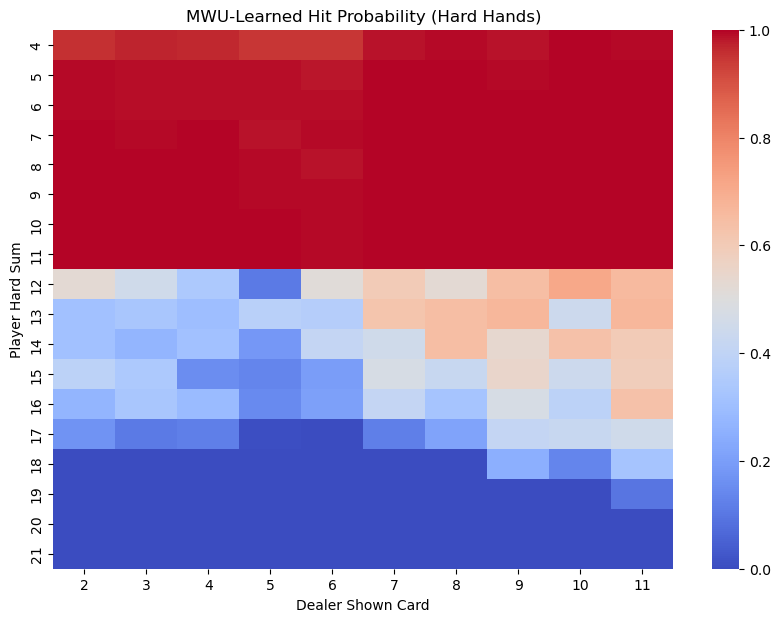

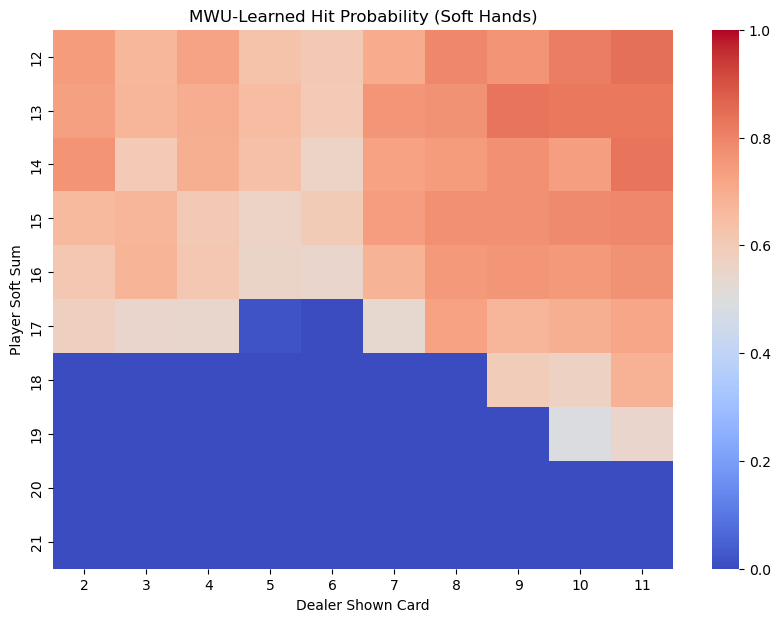

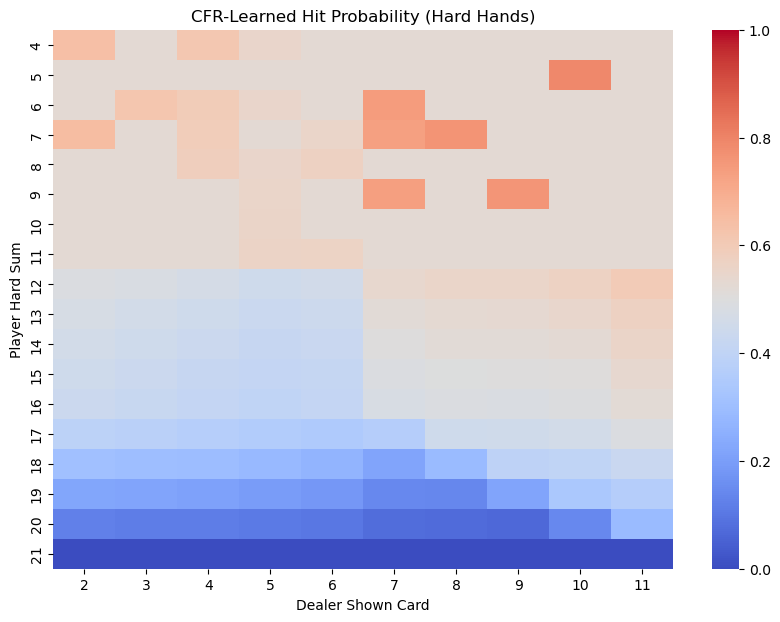

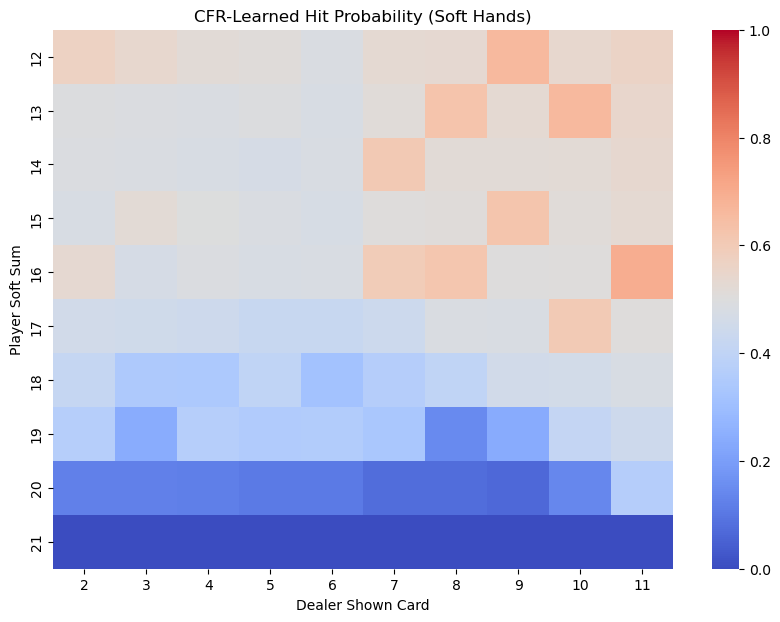

In [4]:
mwu, cfr = simulate(10_000_000)

MWU win rate: 42.01% | CFR win rate: 38.18% after 100000000 rounds


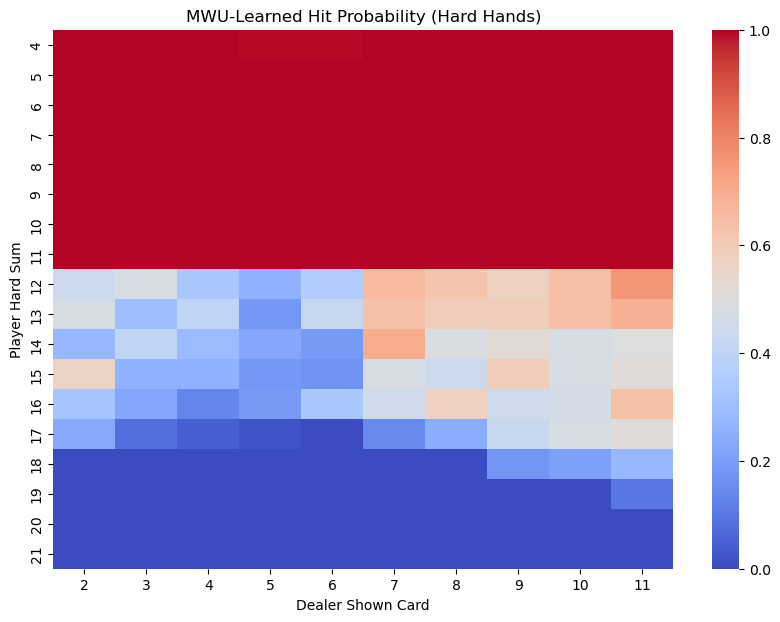

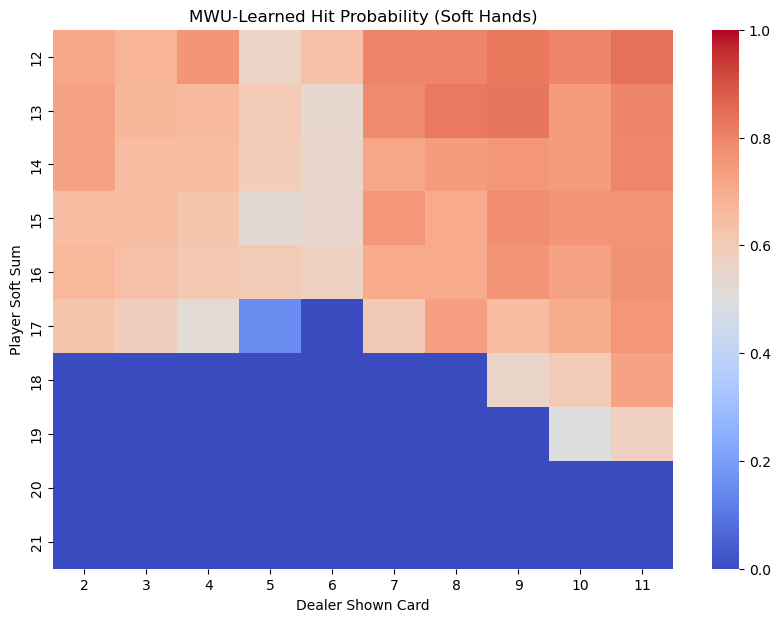

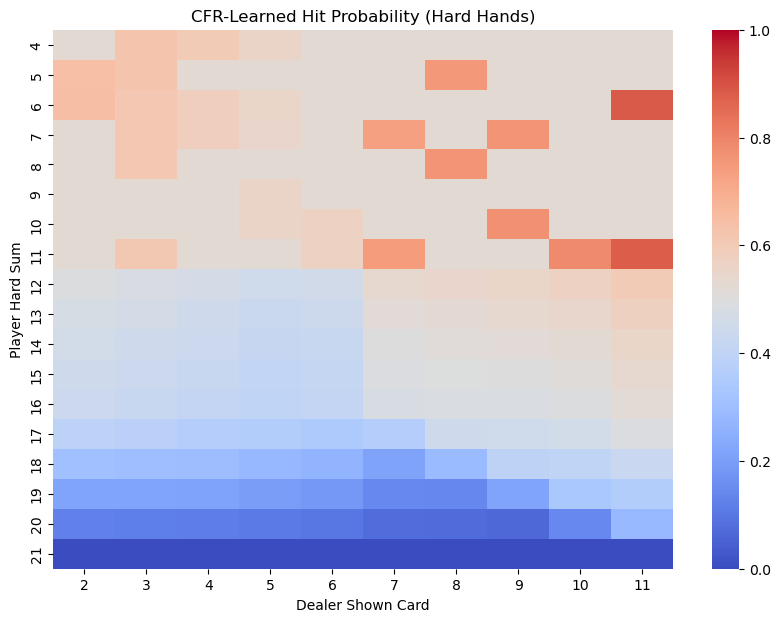

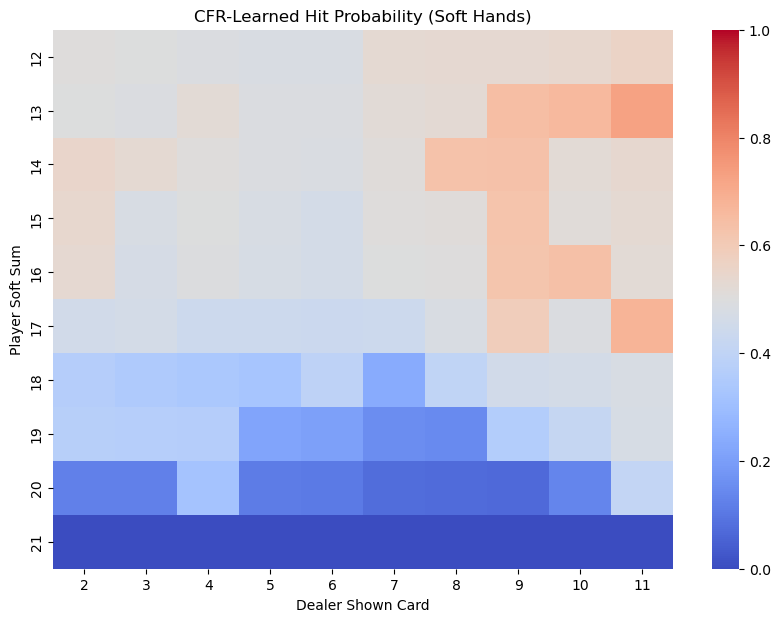

MWU win rate: 42.01% | CFR win rate: 38.18% after 200000000 rounds


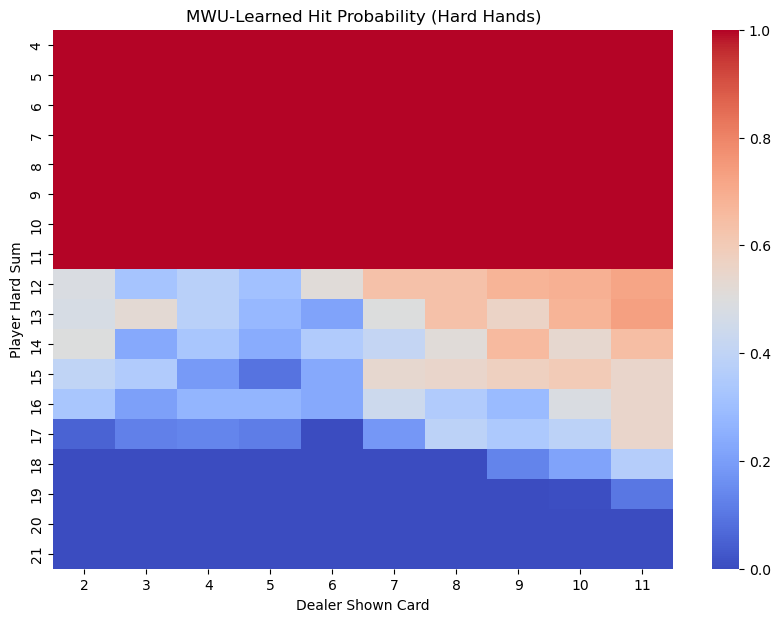

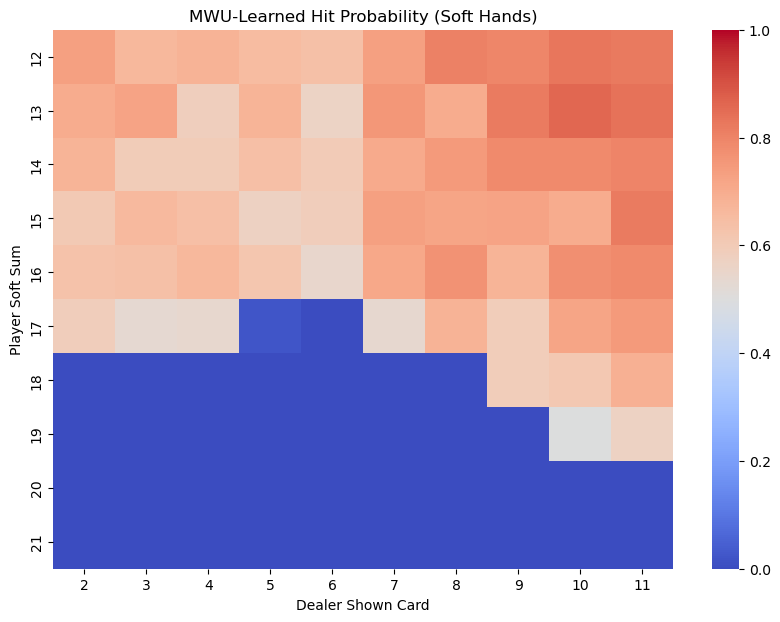

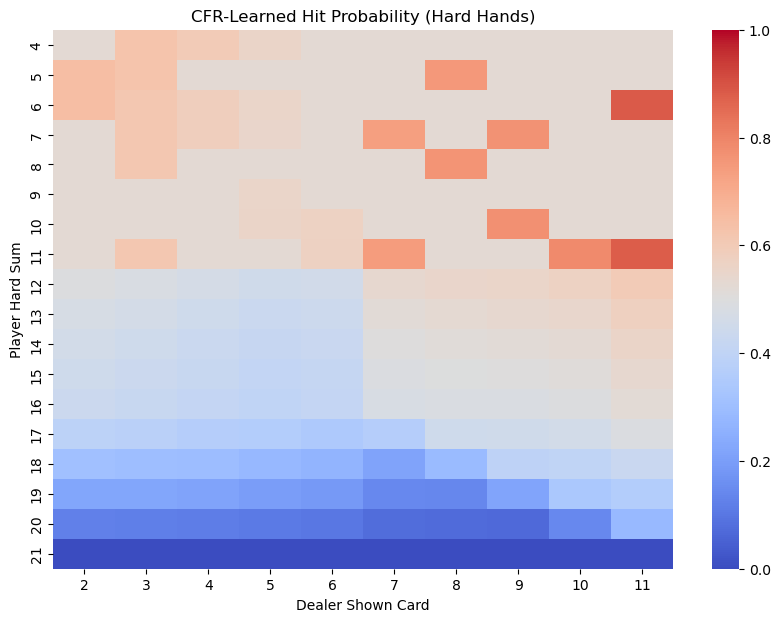

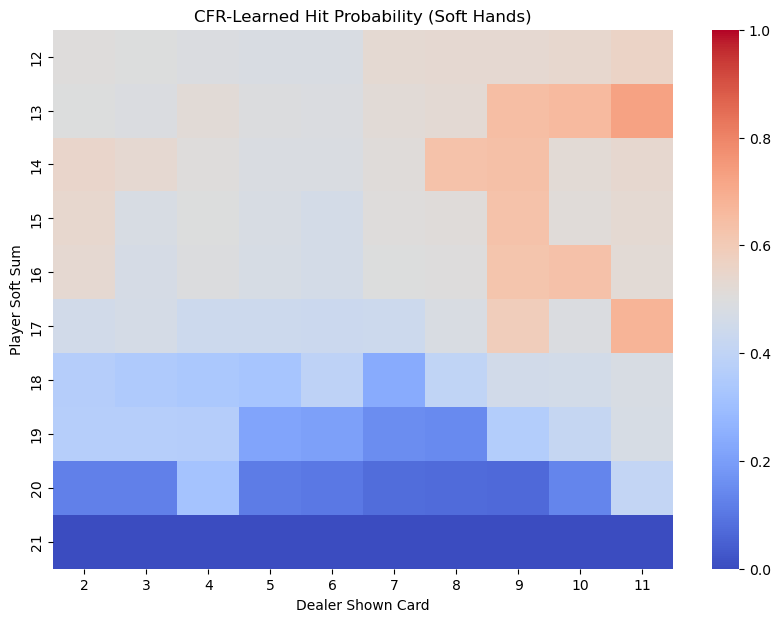

MWU win rate: 42.01% | CFR win rate: 38.18% after 300000000 rounds


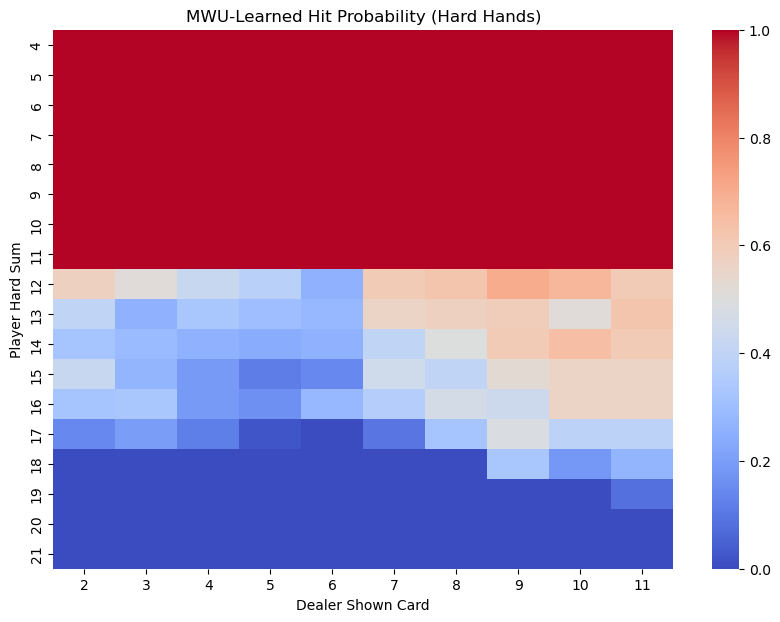

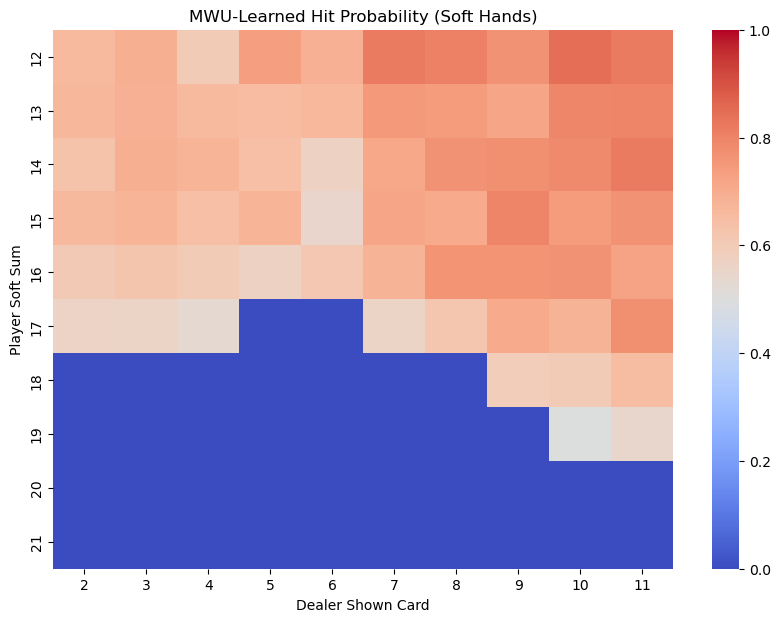

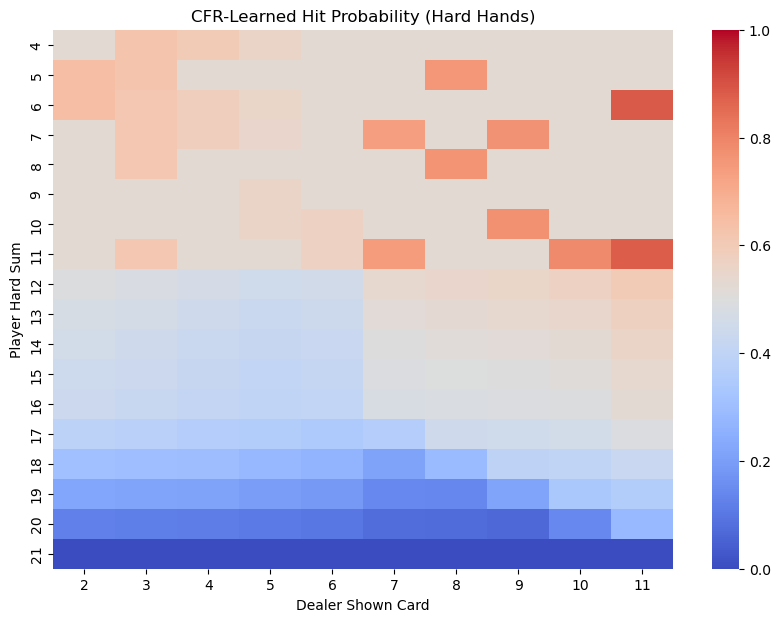

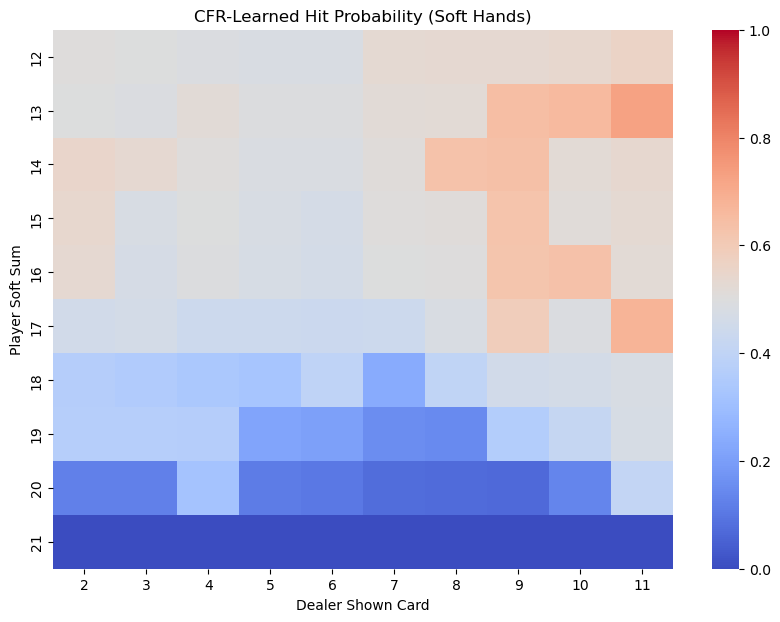

MWU win rate: 42.01% | CFR win rate: 38.18% after 400000000 rounds


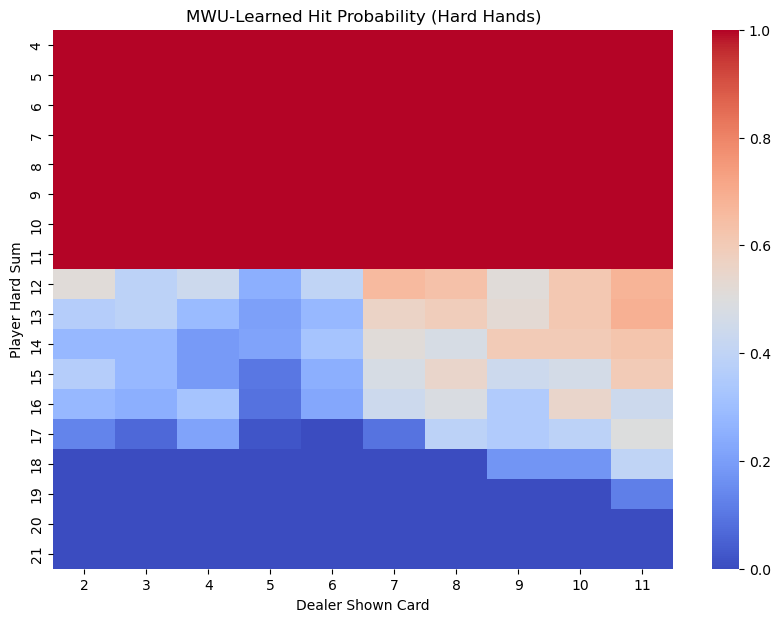

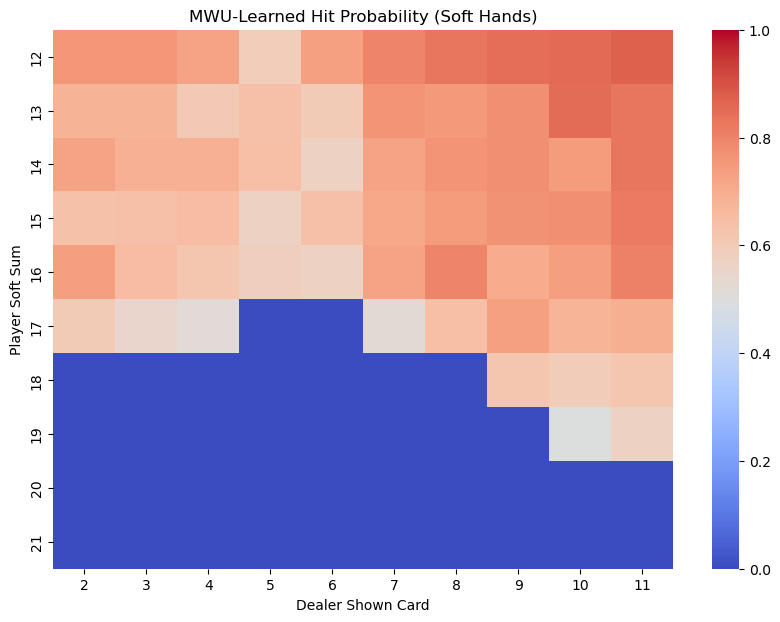

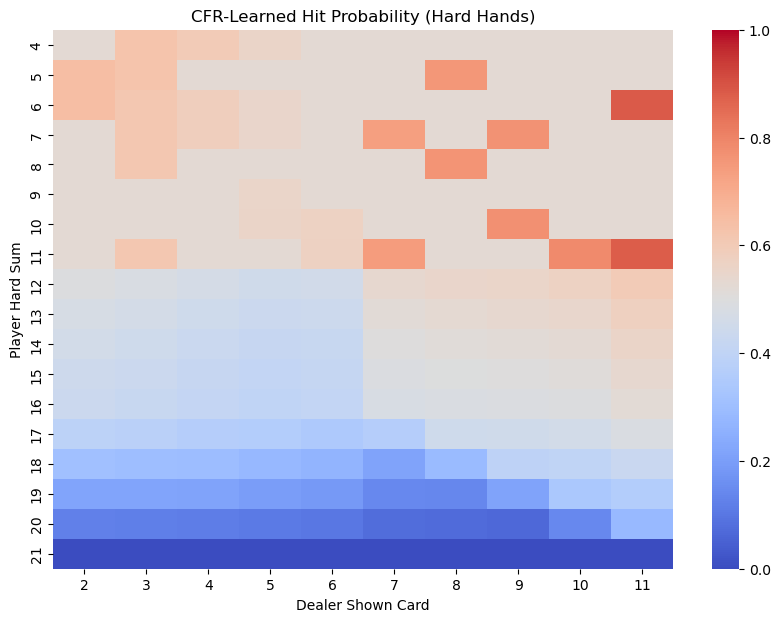

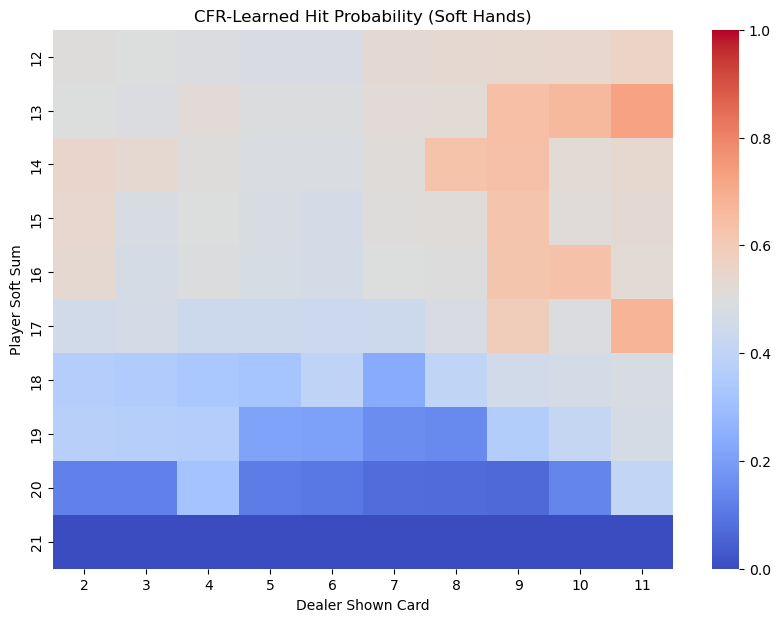

In [8]:
def simulate_long(episodes=100000):
    mwu_agent = MWUAgent(eta=0.05)
    cfr_agent = CFRAgent(eta=0.05)

    results_mwu, results_cfr = [], []

    # === Visualization ===
    def extract_policy_data(agent, table_attr, title_prefix):
        data_hard, data_soft = [], []
        table = getattr(agent, table_attr)
        for state, (v_hit, v_stand) in table.items():
            hit_prob = v_hit / (v_hit + v_stand)
            if len(state) == 2:
                dealer, total = state
                data_hard.append({"Dealer": dealer, "PlayerSum": total, "HitProb": hit_prob})
            elif len(state) == 3:
                dealer, hard, soft = state
                data_soft.append({"Dealer": dealer, "PlayerSum": soft, "HitProb": hit_prob})

        for df, title, ylabel in [
            (data_hard, f"{title_prefix} (Hard Hands)", "Player Hard Sum"),
            (data_soft, f"{title_prefix} (Soft Hands)", "Player Soft Sum"),
        ]:
            if df:
                df = pd.DataFrame(df)
                df_mean = df.groupby(["PlayerSum", "Dealer"], as_index=False)["HitProb"].mean()
                pivot = df_mean.pivot(index="PlayerSum", columns="Dealer", values="HitProb")
                plt.figure(figsize=(10, 7))
                sns.heatmap(pivot, cmap="coolwarm", vmin=0, vmax=1)
                plt.title(title)
                plt.xlabel("Dealer Shown Card")
                plt.ylabel(ylabel)
                plt.show()


    for i in range(episodes):
        # --- MWU ---
        env = BlackJack()
        hard, soft = env.player_values()
        dealer_card = env.dealer_shown
        has_ace = 11 in env.player_hand
        state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
        done = False
        while not done:
            action = mwu_agent.act(state)
            if action == "hit":
                env.player_hand.append(env.draw())
                hard, soft = env.player_values()
                has_ace = 11 in env.player_hand
                if min(hard, soft) > 21:
                    reward = -1
                    done = True
                else:
                    state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
                    continue
            else:
                reward = env.result()
                done = True
            mwu_agent.update(state, action, reward)
            results_mwu.append(reward)

        # --- CFR ---
        env = BlackJack()
        hard, soft = env.player_values()
        dealer_card = env.dealer_shown
        has_ace = 11 in env.player_hand
        state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
        done = False
        while not done:
            action = cfr_agent.act(state)
            if action == "hit":
                env.player_hand.append(env.draw())
                hard, soft = env.player_values()
                has_ace = 11 in env.player_hand
                if min(hard, soft) > 21:
                    reward = -1
                    done = True
                else:
                    state = (dealer_card, hard, soft) if has_ace else (dealer_card, soft)
                    continue
            else:
                reward = env.result()
                done = True
            cfr_agent.update(state, action, reward)
            results_cfr.append(reward)

        if i % 100_000_000 == 0 and i>0:
            # --- Metrics ---
            win_mwu = sum(1 for r in results_mwu if r == 1) / len(results_mwu)
            win_cfr = sum(1 for r in results_cfr if r == 1) / len(results_cfr)
            print(f"MWU win rate: {win_mwu*100:.2f}% | CFR win rate: {win_cfr*100:.2f}% after {i} rounds")

            extract_policy_data(mwu_agent, "weights", "MWU-Learned Hit Probability")
            extract_policy_data(cfr_agent, "strategy_sum", "CFR-Learned Hit Probability")

    return mwu_agent, cfr_agent


mwu, cfr = simulate_long(500_000_000)